<a href="https://colab.research.google.com/github/Roshanraj2580/Rice_Leaf_Detection/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

results_dir = "/content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results"
os.makedirs(results_dir, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize


In [ ]:
# Dataset paths
train_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/train"
val_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/val"
test_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/test"

# Model save directory
model_dir = "/content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "cnn_3layer_rice_leaf_model.keras")

# Results save directory
results_dir = os.path.join(model_dir, "results")
os.makedirs(results_dir, exist_ok=True)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)


Found 1739 images belonging to 4 classes.
Found 367 images belonging to 4 classes.
Found 340 images belonging to 4 classes.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
Train samples: 1739
Val samples: 367
Test samples: 340


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,540 (98.36 MB)

 Trainable params: 25,785,092 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Model saved at:", model_path)


Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.6283 - loss: 2.6169
Epoch 1: val_accuracy improved from None to 0.07084, saving model to /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/cnn_3layer_rice_leaf_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/cnn_3layer_rice_leaf_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 42s 639ms/step - accuracy: 0.7056 - loss: 2.0976 - val_accuracy: 0.0708 - val_loss: 2.6457
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.8005 - loss: 0.8607
Epoch 2: val_accuracy improved from 0.07084 to 0.17166, saving model to /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/cnn_3layer_rice_leaf_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/cnn_3layer_rice_leaf_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 39s 704ms/step - accuracy: 0.8166 - loss: 0.6750 - val_accuracy: 0.1717 - val_loss: 2.8669
Epoch 3/15
55/55 ━━━━━━━━

In [ ]:
best_model = load_model(model_path)
print("Loaded model from:", model_path)


Loaded model from: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/cnn_3layer_rice_leaf_model.keras


In [ ]:
train_loss, train_acc = best_model.evaluate(train_generator, verbose=1)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print("\nCore Metrics")
print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")


55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 592ms/step - accuracy: 0.6895 - loss: 2.0209
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.5286 - loss: 3.8930
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.6706 - loss: 2.9365

Core Metrics
Train Accuracy      : 0.6895
Validation Accuracy : 0.5286
Test Accuracy       : 0.6706
Train Loss          : 2.0209
Validation Loss     : 3.8930
Test Loss           : 2.9365


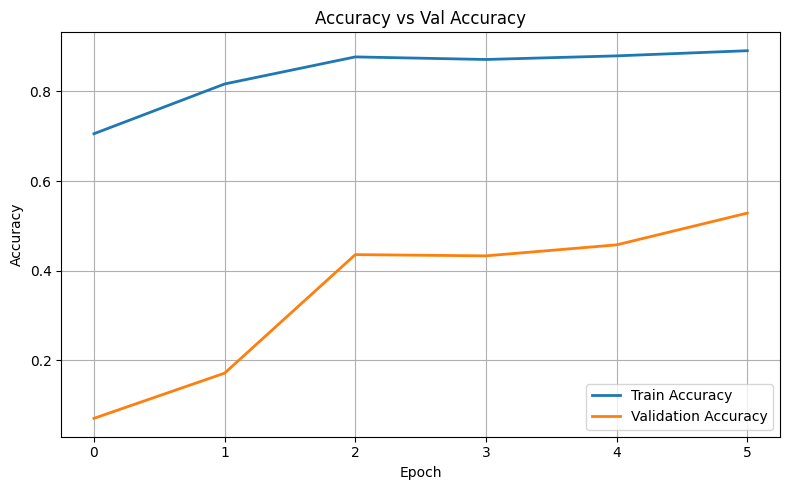

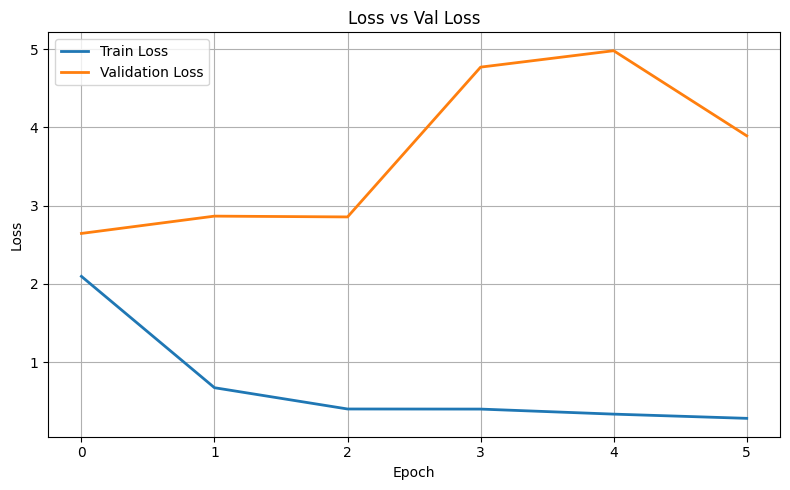

Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/accuracy_vs_val_accuracy.png
Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/loss_vs_val_loss.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Accuracy vs Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_plot_path = os.path.join(results_dir, "accuracy_vs_val_accuracy.png")
plt.savefig(acc_plot_path, dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Loss vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "loss_vs_val_loss.png")
plt.savefig(loss_plot_path, dpi=300)
plt.show()

print("Saved:", acc_plot_path)
print("Saved:", loss_plot_path)


In [ ]:
test_generator.reset()
y_prob = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step


In [ ]:
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
acc = accuracy_score(y_true, y_pred)

print("\nClassification Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Accuracy  : {acc:.4f}")



Classification Metrics
Precision : 0.8130
Recall    : 0.6706
F1-score  : 0.6534
Accuracy  : 0.6706


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report\n")
print(report)

report_path = os.path.join(results_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

print("Saved:", report_path)



Classification Report

                 precision    recall  f1-score   support

Bacterialblight       0.40      0.50      0.44         4
          Blast       0.96      0.33      0.49       160
      Brownspot       0.08      0.75      0.15         4
         Tungro       0.70      0.99      0.82       172

       accuracy                           0.67       340
      macro avg       0.54      0.64      0.48       340
   weighted avg       0.81      0.67      0.65       340

Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/classification_report.txt


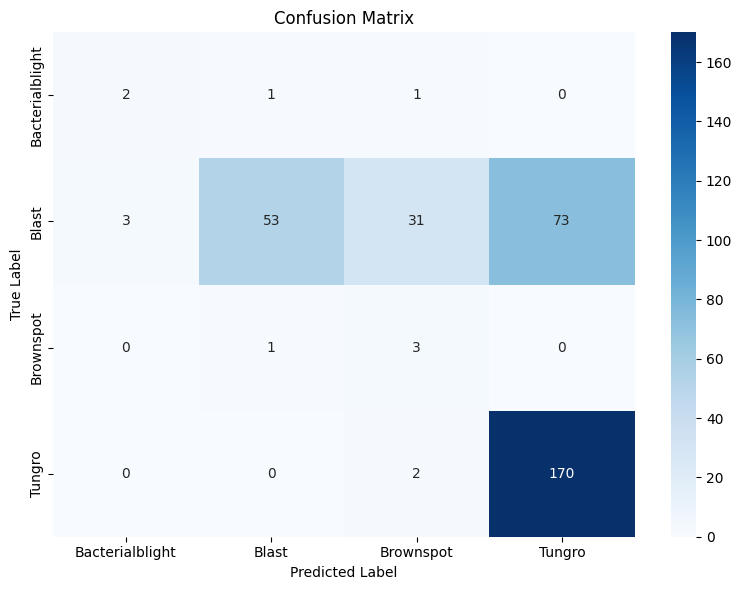

Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(results_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Saved:", cm_path)


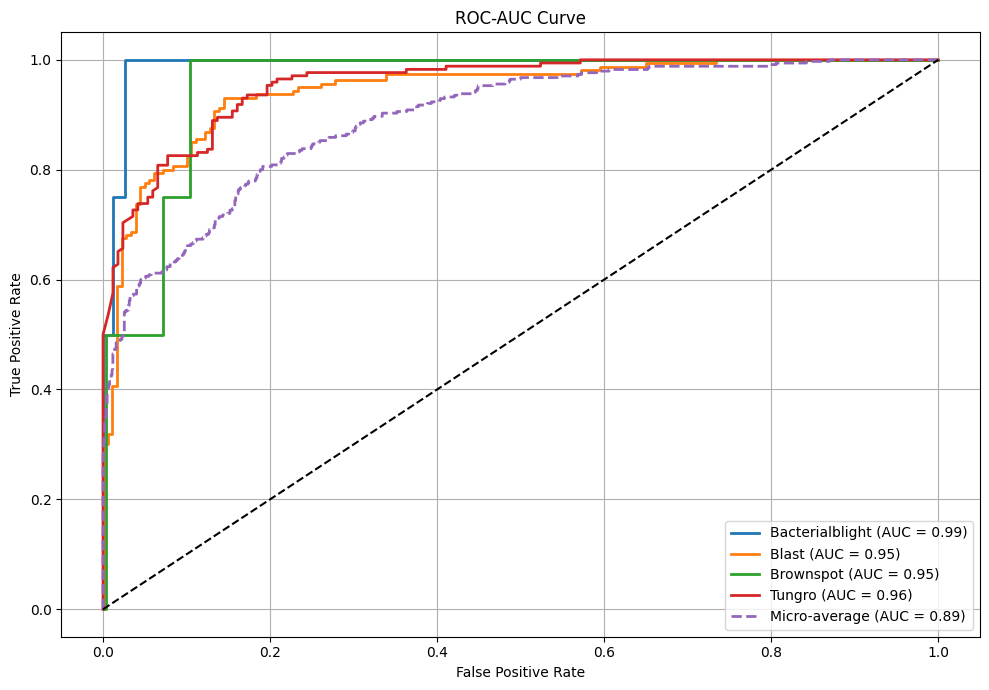

Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/roc_auc_curve.png


In [ ]:
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], linewidth=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, linestyle="--", linewidth=2, label=f"Micro-average (AUC = {roc_auc_micro:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(results_dir, "roc_auc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved:", roc_path)


In [ ]:
roc_auc_macro = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

print("\nROC-AUC Scores")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")

metrics_dict = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_score_weighted": float(f1),
    "test_accuracy_sklearn": float(acc),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted)
}

metrics_path = os.path.join(results_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Saved:", metrics_path)



ROC-AUC Scores
Macro ROC-AUC    : 0.9613
Weighted ROC-AUC : 0.9508
Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/metrics.json


In [ ]:
summary_path = os.path.join(results_dir, "final_metrics_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Evaluation Metrics\n")
    f.write("========================\n\n")
    f.write(f"Train Accuracy      : {train_acc:.4f}\n")
    f.write(f"Validation Accuracy : {val_acc:.4f}\n")
    f.write(f"Test Accuracy       : {test_acc:.4f}\n")
    f.write(f"Train Loss          : {train_loss:.4f}\n")
    f.write(f"Validation Loss     : {val_loss:.4f}\n")
    f.write(f"Test Loss           : {test_loss:.4f}\n")
    f.write(f"Precision           : {precision:.4f}\n")
    f.write(f"Recall              : {recall:.4f}\n")
    f.write(f"F1-score            : {f1:.4f}\n")
    f.write(f"Accuracy            : {acc:.4f}\n")
    f.write(f"Macro ROC-AUC       : {roc_auc_macro:.4f}\n")
    f.write(f"Weighted ROC-AUC    : {roc_auc_weighted:.4f}\n")

print("Saved:", summary_path)
print("\nAll CNN 3-Layer results saved in:", results_dir)


Saved: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results/final_metrics_summary.txt

All CNN 3-Layer results saved in: /content/drive/MyDrive/Minor_Project/Models/CNN 3 Layer/results
